# Tag 01 - Introduction + Regression

This notebook solves the exercises for Day 1.

## Exercises
1. Regression Energy
2. Regression Life Data

## Required data files
Put these files into the `data` folder:

- `energy_data.csv`
- `life_data.csv`

Expected path:

`Tag_01_Einfuehrung_Regression/data/`

## Dataset Validation
Run this cell to verify that your datasets are present and correctly formatted.

In [1]:
# --- DATASET VALIDATION ---
import os
import pandas as pd

def validate_dataset(filepath, expected_columns=None, avoid_columns=None):
    if not os.path.exists(filepath):
        print(f'❌ ERROR: Dataset not found at {filepath}')
        return False
    try:
        df = pd.read_csv(filepath, nrows=5)
        print(f'✅ SUCCESS: Dataset found at {filepath} (Columns: {df.shape[1]})')
        if expected_columns:
            missing = [c for c in expected_columns if c not in df.columns]
            if missing:
                print(f'⚠️ WARNING: Missing expected columns: {missing}')
                return False
        if avoid_columns:
            forbidden = [c for c in avoid_columns if c in df.columns]
            if forbidden:
                print(f'❌ ERROR: Found forbidden columns {forbidden}. Wrong dataset!')
                return False
        return True
    except Exception as e:
        print(f'❌ ERROR: Could not read dataset: {e}')
        return False

print('Validation helper loaded. Call validate_dataset(path) before loading your data.')
# validate_dataset('../data/your_dataset.csv')

Validation helper loaded. Call validate_dataset(path) before loading your data.


In [2]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [3]:
# Project paths

BASE_DIR = Path.cwd()

# If the notebook is executed from the exercise folder,
# go one level up to Tag_01_Einfuehrung_Regression
if BASE_DIR.name in ["exercise", "notebooks"]:
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Base folder:", BASE_DIR)
print("Data folder:", DATA_DIR)
print("Output folder:", OUTPUT_DIR)

Base folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\01-ml-engineering-foundations
Data folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\01-ml-engineering-foundations\data
Output folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\01-ml-engineering-foundations\output


In [4]:
# Helper functions

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

def save_plot(filename):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)

# Exercise 1 - Regression Energy

Goal: Predict `Energy Consumption`.

Important concepts:
- Features and target
- Regression
- One-Hot-Encoding
- Train/Test Split
- MAE, MSE, RMSE, R2

In [5]:
energy_path = DATA_DIR / "energy_data.csv"

if not energy_path.exists():
    raise FileNotFoundError(f"energy_data.csv not found here: {energy_path}")

df_energy = pd.read_csv(energy_path)

if "Unnamed: 0" in df_energy.columns:
    df_energy = df_energy.drop(columns=["Unnamed: 0"])

df_energy.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [6]:
print("Shape:", df_energy.shape)
print("\nColumns:")
print(df_energy.columns)

print("\nMissing values:")
print(df_energy.isnull().sum())

df_energy.describe(include="all")

Shape: (1100, 7)

Columns:
Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

Missing values:
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
count,1100,1100.000000,1100.000000,1100.000000,1100.000000,1100,1100.000000
unique,3,NaN,NaN,NaN,NaN,2,NaN
top,Residential,NaN,NaN,NaN,NaN,Weekday,NaN
freq,387,NaN,NaN,NaN,NaN,551,NaN
mean,NaN,25500.527273,48.268182,25.730000,22.559745,NaN,4168.191273
std,NaN,14236.955632,29.127624,14.116209,7.122357,NaN,924.278723
min,NaN,560.000000,1.000000,1.000000,10.050000,NaN,1683.950000
25%,NaN,13203.750000,22.000000,13.000000,16.365000,NaN,3510.460000
50%,NaN,25785.500000,47.000000,26.000000,22.810000,NaN,4189.690000
75%,NaN,37536.750000,73.000000,38.000000,28.760000,NaN,4859.510000


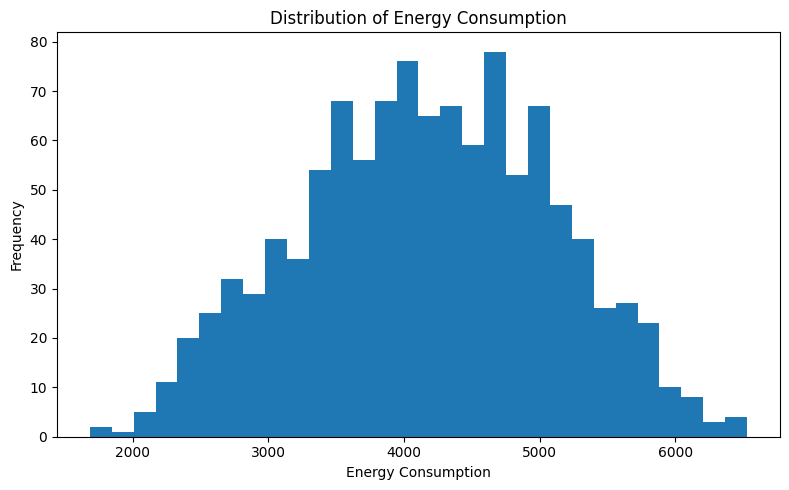

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\01-ml-engineering-foundations\output\day01_energy_distribution.png


In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df_energy["Energy Consumption"], bins=30)
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption")
plt.ylabel("Frequency")
save_plot("day01_energy_distribution.png")

In [8]:
print("Average Energy Consumption by Day of Week:")
display(df_energy.groupby("Day of Week")["Energy Consumption"].mean())

print("Average Energy Consumption by Building Type:")
display(df_energy.groupby("Building Type")["Energy Consumption"].mean())

Average Energy Consumption by Day of Week:


Day of Week
Weekday    4184.314719
Weekend    4152.009089
Name: Energy Consumption, dtype: float64

Average Energy Consumption by Building Type:


Building Type
Commercial     4152.745359
Industrial     4716.354701
Residential    3685.467907
Name: Energy Consumption, dtype: float64

In [9]:
# One-Hot-Encoding for categorical columns

df_energy_encoded = pd.get_dummies(
    df_energy,
    columns=["Building Type", "Day of Week"],
    drop_first=True
)

df_energy_encoded.columns = [
    col.strip().replace(" ", "_").replace("-", "_").replace("/", "_")
    for col in df_energy_encoded.columns
]

df_energy_encoded.head()

,Square_Footage,Number_of_Occupants,Appliances_Used,Average_Temperature,Energy_Consumption,Building_Type_Industrial,Building_Type_Residential,Day_of_Week_Weekend
0,7063,76,10,29.84,2713.95,False,True,False
1,44372,66,45,16.72,5744.99,False,False,False
2,19255,37,17,14.30,4101.24,True,False,True
3,13265,14,41,32.82,3009.14,False,True,False
4,13375,26,18,11.92,3279.17,False,False,False


In [10]:
target = "Energy_Consumption"

X = df_energy_encoded.drop(columns=[target])
y = df_energy_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model_energy = LinearRegression()
model_energy.fit(X_train, y_train)

y_pred_energy = model_energy.predict(X_test)

metrics_energy = regression_metrics(y_test, y_pred_energy)
metrics_energy

{'MAE': 0.011975550249830618,
 'MSE': 0.00019914006270836936,
 'RMSE': 0.014111699497522237,
 'R2': 0.9999999997658856}

In [11]:
energy_results = pd.DataFrame({
    "Metric": list(metrics_energy.keys()),
    "Value": list(metrics_energy.values())
})

display(energy_results)

energy_results.to_csv(OUTPUT_DIR / "day01_energy_metrics.csv", index=False)

,Metric,Value
0,MAE,0.011976
1,MSE,0.000199
2,RMSE,0.014112
3,R2,1.000000


In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_energy.coef_,
    "Absolute_Importance": np.abs(model_energy.coef_)
}).sort_values("Absolute_Importance", ascending=False)

display(coefficients)

coefficients.to_csv(OUTPUT_DIR / "day01_energy_coefficients.csv", index=False)

,Feature,Coefficient,Absolute_Importance
4,Building_Type_Industrial,500.000911,500.000911
5,Building_Type_Residential,-499.999781,499.999781
6,Day_of_Week_Weekend,-50.001671,50.001671
2,Appliances_Used,20.000013,20.000013
1,Number_of_Occupants,10.000001,10.000001
3,Average_Temperature,-4.999993,4.999993
0,Square_Footage,0.050000,0.050000


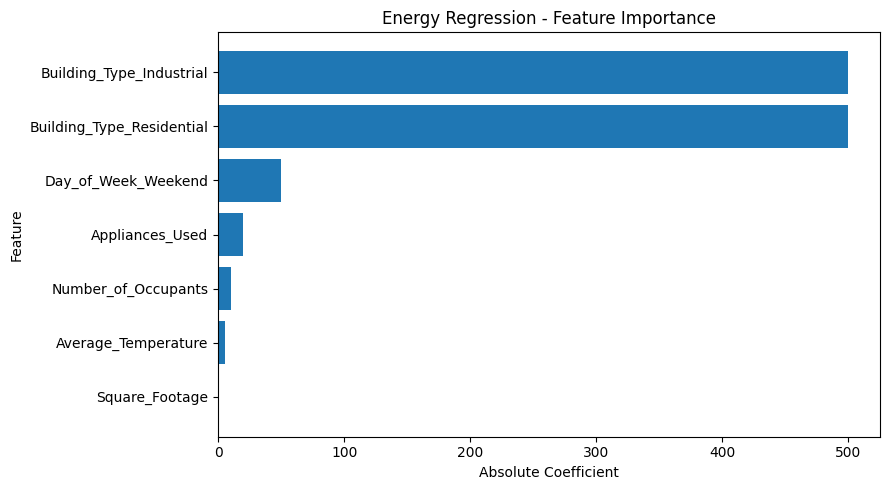

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\01-ml-engineering-foundations\output\day01_energy_feature_importance.png


In [13]:
plt.figure(figsize=(9, 5))
plt.barh(coefficients["Feature"], coefficients["Absolute_Importance"])
plt.title("Energy Regression - Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
save_plot("day01_energy_feature_importance.png")

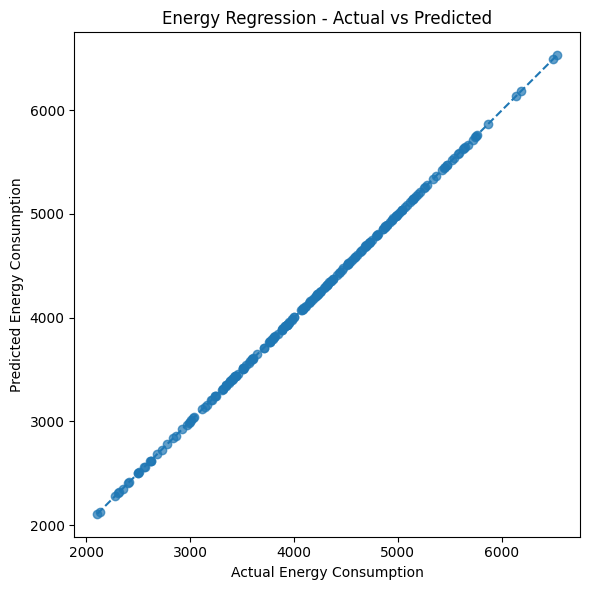

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\01-ml-engineering-foundations\output\day01_energy_actual_vs_predicted.png


In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_energy, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Energy Regression - Actual vs Predicted")
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
save_plot("day01_energy_actual_vs_predicted.png")

In [15]:
energy_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_energy
})

display(energy_predictions.head(10))

energy_predictions.to_csv(OUTPUT_DIR / "day01_energy_predictions.csv", index=False)

,Actual,Predicted
0,3708.08,3708.101727
1,3372.20,3372.200768
2,5023.85,5023.849994
3,3314.91,3314.898620
4,3984.20,3984.199376
5,4516.02,4516.000159
6,2728.63,2728.649164
7,4374.33,4374.348030
8,5763.85,5763.849432
9,3796.71,3796.700730


# Exercise 2 - Regression Life Data

Goal: Predict life expectancy.

Important concepts:
- Missing values
- Target selection
- Encoding categorical features
- Model comparison
- RMSE and R2

In [16]:
life_path = DATA_DIR / "life_data.csv"

if not life_path.exists():
    raise FileNotFoundError(f"life_data.csv not found here: {life_path}")

df_life = pd.read_csv(life_path)
df_life.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [17]:
print("Shape:", df_life.shape)
print("\nColumns:")
print(df_life.columns)

print("\nMissing values:")
display(df_life.isnull().sum().sort_values(ascending=False))

df_life.describe(include="all")

Shape: (2938, 22)

Columns:
Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

Missing values:


Population                         652
Hepatitis B                        553
GDP                                448
Total expenditure                  226
Alcohol                            194
Income composition of resources    167
Schooling                          163
 thinness 5-9 years                 34
 thinness  1-19 years               34
 BMI                                34
Polio                               19
Diphtheria                          19
Life expectancy                     10
Adult Mortality                     10
 HIV/AIDS                            0
Country                              0
Year                                 0
Measles                              0
percentage expenditure               0
infant deaths                        0
Status                               0
under-five deaths                    0
dtype: int64

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938,2938.000000,2938,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,...,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
unique,193,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,Developing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,16,NaN,2426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2007.518720,NaN,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,...,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,NaN,4.613841,NaN,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,...,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,NaN,2000.000000,NaN,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,...,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,NaN,2004.000000,NaN,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,...,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,NaN,2008.000000,NaN,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,...,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,NaN,2012.000000,NaN,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,...,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000


In [18]:
df_life_model = df_life.copy()

# Remove text column for this simple regression exercise
if "Country" in df_life_model.columns:
    df_life_model = df_life_model.drop(columns=["Country"])

# Remove Year to keep the first model simple
if "Year" in df_life_model.columns:
    df_life_model = df_life_model.drop(columns=["Year"])

# Encode Status if it exists
if "Status" in df_life_model.columns:
    le = LabelEncoder()
    df_life_model["Status"] = le.fit_transform(df_life_model["Status"].astype(str))

df_life_model.head()

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [19]:
# Fill missing values with mean

imputer = SimpleImputer(strategy="mean")

df_life_imputed = pd.DataFrame(
    imputer.fit_transform(df_life_model),
    columns=df_life_model.columns
)

df_life_imputed.isnull().sum().sum()

0

In [20]:
target_life = "Life expectancy "

if target_life not in df_life_imputed.columns:
    print("Available columns:")
    print(df_life_imputed.columns)
    raise ValueError("Target column 'Life expectancy ' not found. Check exact column name.")

corr = df_life_imputed.corr(numeric_only=True)
life_corr = corr[target_life].sort_values(ascending=False)

life_corr

Life expectancy                    1.000000
Schooling                          0.715066
Income composition of resources    0.692483
 BMI                               0.559255
Diphtheria                         0.475418
Polio                              0.461574
GDP                                0.430493
Alcohol                            0.391598
percentage expenditure             0.381791
Total expenditure                  0.207981
Hepatitis B                        0.203771
Population                        -0.019638
Measles                           -0.157574
infant deaths                     -0.196535
under-five deaths                 -0.222503
 thinness 5-9 years               -0.466629
 thinness  1-19 years             -0.472162
Status                            -0.481962
 HIV/AIDS                         -0.556457
Adult Mortality                   -0.696359
Name: Life expectancy , dtype: float64

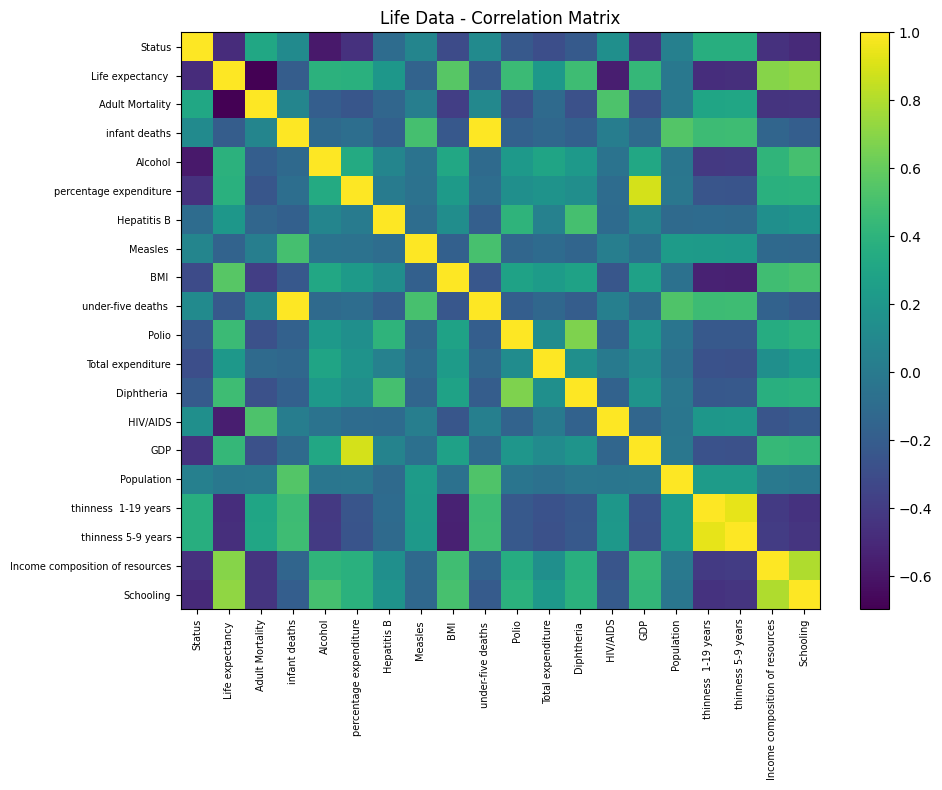

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\01-ml-engineering-foundations\output\day01_life_correlation_matrix.png


In [21]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Life Data - Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)
save_plot("day01_life_correlation_matrix.png")

In [22]:
X_life = df_life_imputed.drop(columns=[target_life])
y_life = df_life_imputed[target_life]

X_train, X_test, y_train, y_test = train_test_split(
    X_life,
    y_life,
    test_size=0.20,
    random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(max_iter=10000),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    metrics = regression_metrics(y_test, y_pred)
    results.append({
        "Model": name,
        "MAE": round(metrics["MAE"], 4),
        "MSE": round(metrics["MSE"], 4),
        "RMSE": round(metrics["RMSE"], 4),
        "R2": round(metrics["R2"], 4)
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

results_df.to_csv(OUTPUT_DIR / "day01_life_model_comparison.csv", index=False)

,Model,MAE,MSE,RMSE,R2
3,Random Forest,1.0665,2.7176,1.6485,0.9686
1,Ridge Regression,2.8572,15.2202,3.9013,0.8243
0,Linear Regression,2.8579,15.2380,3.9036,0.8241
2,Lasso Regression,2.9033,15.8806,3.9851,0.8167


In [23]:
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


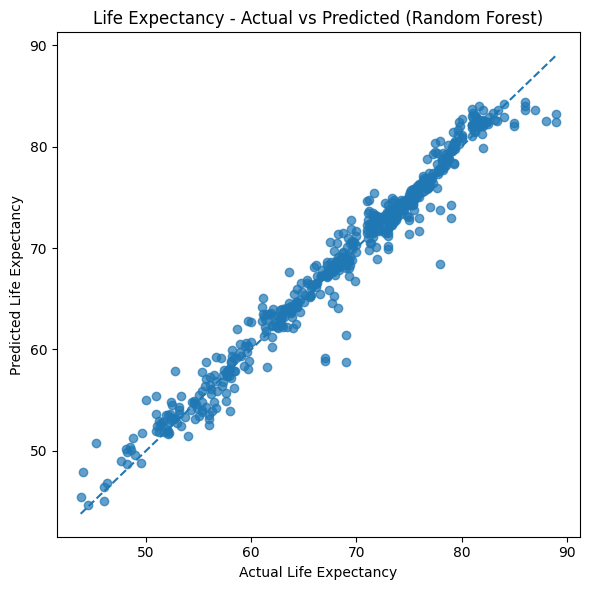

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\01-ml-engineering-foundations\output\day01_life_actual_vs_predicted.png


In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title(f"Life Expectancy - Actual vs Predicted ({best_model_name})")
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
save_plot("day01_life_actual_vs_predicted.png")

In [25]:
life_predictions = pd.DataFrame({
    "Actual_Life_Expectancy": y_test.values,
    "Predicted_Life_Expectancy": best_pred
})

display(life_predictions.head(10))

life_predictions.to_csv(OUTPUT_DIR / "day01_life_predictions.csv", index=False)

,Actual_Life_Expectancy,Predicted_Life_Expectancy
0,73.7,72.902
1,75.9,76.052
2,74.2,74.778
3,76.8,75.919
4,51.9,53.505
5,49.6,51.777
6,67.4,65.883
7,73.9,73.834
8,77.2,76.909
9,55.0,55.536


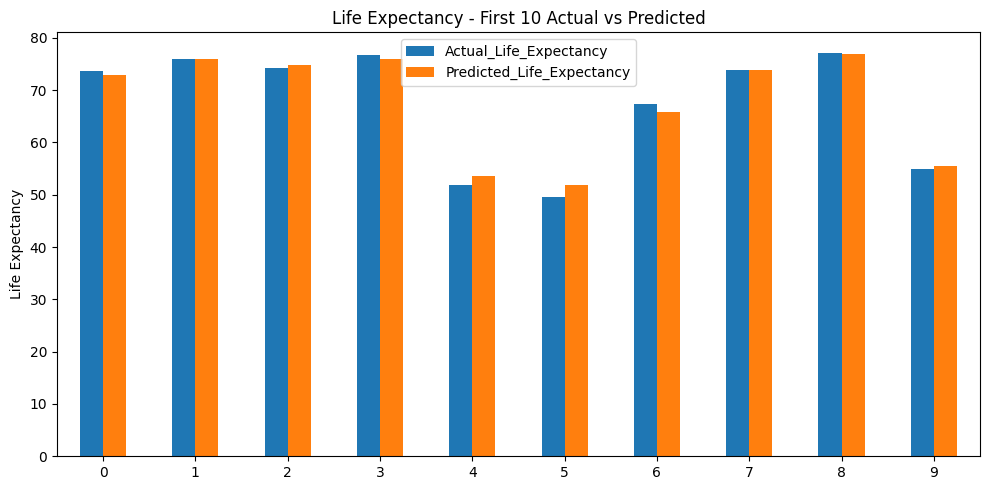

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\01-ml-engineering-foundations\output\day01_life_first10_comparison.png


In [26]:
life_predictions.head(10).plot(kind="bar", figsize=(10, 5))
plt.title("Life Expectancy - First 10 Actual vs Predicted")
plt.ylabel("Life Expectancy")
plt.xticks(rotation=0)
save_plot("day01_life_first10_comparison.png")

# Day 01 Summary

In Day 1 we learned:

- Machine Learning learns the relationship between features and a target.
- Regression predicts continuous numerical values.
- Regression can be evaluated using MAE, MSE, RMSE and R2.
- R2 close to 1 means the model explains much of the target variation.
- Train/Test Split is needed to evaluate the model on unseen data.
- Categorical features must be encoded before modeling.